# 🧬 Distributed Genomic Sequencing for Rare Disease Identification
### Big Data + Machine Learning Pipeline | Google Colab + PySpark

---

## 📋 Project Overview

This pipeline analyzes **real human genomic mutation data** from NCBI ClinVar to:
- Identify mutation patterns linked to **rare genetic diseases**
- Apply **K-Means clustering** to group similar mutations
- Apply **Random Forest classification** to predict disease severity
- Use **Apache Spark** for distributed processing of 2M+ records

## 📦 Dataset: ClinVar Variant Summary (NCBI)
| Attribute | Details |
|---|---|
| **Source** | NCBI National Center for Biotechnology Information |
| **URL** | https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/ |
| **File** | variant_summary.txt.gz (~200MB compressed) |
| **Records** | 2,000,000+ genetic variant entries |
| **License** | Public Domain (US Government / NCBI) |

### Why ClinVar?
- World's largest curated database of human genetic variants
- Maps mutations → clinical significance → diseases
- Used by hospitals, researchers, and genomic labs worldwide
- Contains `GeneSymbol`, `ClinicalSignificance`, `Chromosome`, `Start` — exactly what we need

### How It Helps Rare Disease Identification
- **Pathogenic** variants = confirmed disease-causing mutations
- Clustering reveals genes sharing similar mutation profiles
- Classification model can predict severity of unseen mutations

---

## 📁 Directory Structure
```
/content/drive/MyDrive/genomic_project/
├── data/           ← raw ClinVar .gz file
├── processed/      ← cleaned Parquet checkpoints
├── models/         ← saved ML models
├── outputs/        ← final CSV + evaluation results
└── notebooks/      ← this notebook
```

---
## ⚙️ ENVIRONMENT SETUP
Install PySpark and required libraries

In [ ]:
# ============================================================
# ENVIRONMENT SETUP — Install PySpark & Dependencies
# ============================================================
!pip install pyspark==3.5.0 --quiet
!pip install findspark --quiet

import findspark
findspark.init()

# Standard imports
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

# PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import (
    StringIndexer, VectorAssembler, StandardScaler, MinMaxScaler
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (
    ClusteringEvaluator, MulticlassClassificationEvaluator
)
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Data & ML imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import joblib

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [ ]:
# ============================================================
# SPARK SESSION INITIALIZATION
# ============================================================
spark = (
    SparkSession.builder
    .appName('GenomicRareDiseaseIdentification')
    .config('spark.driver.memory', '4g')
    .config('spark.executor.memory', '4g')
    .config('spark.sql.shuffle.partitions', '50')
    .config('spark.default.parallelism', '50')
    .config('spark.sql.adaptive.enabled', 'true')
    .config('spark.driver.maxResultSize', '2g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')
print(f'✅ Spark Session Created')
print(f'   Version     : {spark.version}')
print(f'   App Name    : {spark.sparkContext.appName}')
print(f'   Master      : {spark.sparkContext.master}')

✅ Spark Session Created
   Version     : 3.5.0
   App Name    : GenomicRareDiseaseIdentification
   Master      : local[*]


---
## 🗂️ GOOGLE DRIVE SETUP + DIRECTORY STRUCTURE

In [19]:
# ============================================================
# GOOGLE DRIVE MOUNT + PROJECT DIRECTORY SETUP
# ============================================================
from google.colab import drive
import os # Ensure os is imported for directory operations

# ── Define all project paths ──────────────────────────────────
# Define these early so they are available even if mount fails initially
BASE_DIR        = '/content/drive/MyDrive/genomic_project'
DATA_DIR        = f'{BASE_DIR}/data'
PROCESSED_DIR   = f'{BASE_DIR}/processed'
MODELS_DIR      = f'{BASE_DIR}/models'
OUTPUTS_DIR     = f'{BASE_DIR}/outputs'
NOTEBOOKS_DIR   = f'{BASE_DIR}/notebooks'

mount_successful = False
try:
    drive.mount('/content/drive', force_remount=True)
    print('✅ Google Drive mounted')
    mount_successful = True
except Exception as e:
    print(f'⚠️  Google Drive mount failed: {e}. Please try re-running this cell to authorize Google Drive.')
    print('   Alternatively, check your internet connection or Google Drive status.')

# Explicitly check if the mount point is accessible
if os.path.exists('/content/drive/MyDrive'):
    print('✅ Google Drive mount point accessible.')
    mount_successful = True
else:
    print('❌ ERROR: /content/drive/MyDrive is not accessible. Please ensure Google Drive is mounted successfully.')
    print('   You MUST re-run this cell and follow the authentication prompts if necessary.')
    mount_successful = False

# ── Create directories if they don't exist ───────────────────
if mount_successful: # Only create directories if mount is successful
    for directory in [DATA_DIR, PROCESSED_DIR, MODELS_DIR, OUTPUTS_DIR, NOTEBOOKS_DIR]:
        os.makedirs(directory, exist_ok=True)
    print('✅ Project directory structure created:')
    print(f'   📂 {BASE_DIR}/')
    print(f'   ├── 📂 data/')
    print(f'   ├── 📂 processed/')
    print(f'   ├── 📂 models/')
    print(f'   ├── 📂 outputs/')
    print(f'   └── 📂 notebooks/')
else:
    print('⚠️  Skipping directory creation as Google Drive is not mounted.')
    print('   Please ensure Google Drive is mounted correctly to proceed with saving files.')


⚠️  Google Drive mount failed: Mountpoint must not already contain files. Please try re-running this cell to authorize Google Drive.
   Alternatively, check your internet connection or Google Drive status.
✅ Google Drive mount point accessible.
✅ Project directory structure created:
   📂 /content/drive/MyDrive/genomic_project/
   ├── 📂 data/
   ├── 📂 processed/
   ├── 📂 models/
   ├── 📂 outputs/
   └── 📂 notebooks/


In [20]:
# ============================================================
# HELPER FUNCTIONS for Checkpointing
# ============================================================
# These functions manage saving and loading intermediate dataframes
# to Google Drive, allowing quick restarts and avoiding re-running
# costly computations.

def checkpoint_exists(path):
    """Checks if a file or directory at the given path exists."""
    # For Spark, check if _SUCCESS file exists in directory
    if spark._jvm.org.apache.hadoop.fs.FileSystem.get(spark._jsc.hadoopConfiguration()).exists(
        spark._jvm.org.apache.hadoop.fs.Path(f'{path}/_SUCCESS')
    ):
        print(f'   ✅ Checkpoint exists: {path}')
        return True
    # For single files, check directly
    if os.path.exists(path):
        print(f'   ✅ Checkpoint exists: {path}')
        return True
    return False

def save_parquet(df, path, name='Data'):
    """Saves a Spark DataFrame as Parquet and confirms success."""
    print(f'   ⏳ Saving {name} to Parquet: {path}')
    start_time = time.time()
    df.write.mode('overwrite').parquet(path)
    elapsed = time.time() - start_time
    print(f'   ✅ {name} saved in {elapsed:.1f} seconds')

def load_parquet(path, name='Data'):
    """Loads a Spark DataFrame from Parquet and confirms success."""
    print(f'   ⏳ Loading {name} from Parquet: {path}')
    start_time = time.time()
    df = spark.read.parquet(path)
    elapsed = time.time() - start_time
    print(f'   ✅ {name} loaded in {elapsed:.1f} seconds | Rows: {df.count():,}')
    return df

print('✅ Checkpointing helper functions defined.')

✅ Checkpointing helper functions defined.


---
## 📥 MODULE 1: DATA INGESTION
### What happens here:
- Check if ClinVar dataset already downloaded
- If not → download from NCBI FTP (official public source)
- Load `.gz` compressed TSV directly into Spark DataFrame
- Display schema and sample rows

**Expected Output:** Spark DataFrame with 2M+ rows, schema printed

In [21]:
# ============================================================
# MODULE 1: DATA INGESTION
# ============================================================

DATASET_URL  = 'https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz'
DATASET_PATH = f'{DATA_DIR}/variant_summary.txt.gz'
RAW_PARQUET  = f'{PROCESSED_DIR}/raw_spark_df'

# ── Step 1A: Download dataset only if not present ────────────
if checkpoint_exists(DATASET_PATH):
    print(f'✅ Dataset already exists at: {DATASET_PATH}')
    print(f'   Skipping download.')
else:
    print('📥 Downloading ClinVar dataset from NCBI...')
    print(f'   Source : {DATASET_URL}')
    print(f'   Target : {DATASET_PATH}')
    print('   This may take 3–5 minutes (~200MB)...')
    start_time = time.time()
    !wget -q --show-progress -O "{DATASET_PATH}" "{DATASET_URL}"
    elapsed = time.time() - start_time
    file_size_mb = os.path.getsize(DATASET_PATH) / (1024 * 1024)
    print(f'✅ Download complete!')
    print(f'   File size : {file_size_mb:.1f} MB')
    print(f'   Time      : {elapsed:.1f} seconds')

print(f'\n📂 Dataset location: {DATASET_PATH}')

📥 Downloading ClinVar dataset from NCBI...
   Source : https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz
   Target : /content/drive/MyDrive/genomic_project/data/variant_summary.txt.gz
   This may take 3–5 minutes (~200MB)...
/content/drive/MyDr 100%[===================>] 415.40M  47.0MB/s    in 7.9s    
✅ Download complete!
   File size : 415.4 MB
   Time      : 8.3 seconds

📂 Dataset location: /content/drive/MyDrive/genomic_project/data/variant_summary.txt.gz


In [22]:
# ── Step 1B: Load into Spark DataFrame ───────────────────────
# PySpark can read .gz files natively — no decompression needed

if checkpoint_exists(RAW_PARQUET):
    print('🔄 Loading raw data from Parquet checkpoint...')
    raw_df = load_parquet(RAW_PARQUET, 'RAW')
else:
    print('⚙️  Loading ClinVar .gz file into Spark...')
    raw_df = (
        spark.read
        .option('header', 'true')
        .option('sep', '\t')
        .option('inferSchema', 'true')
        .option('multiLine', 'false')
        .option('escape', '"')
        .csv(DATASET_PATH)
    )
    print(f'   ✅ Spark DataFrame created')
    # Save raw checkpoint to avoid re-reading .gz next time
    save_parquet(raw_df, RAW_PARQUET, 'RAW')

print(f'\n📊 Raw DataFrame Info:')
print(f'   Rows    : {raw_df.count():,}')
print(f'   Columns : {len(raw_df.columns)}')

⚙️  Loading ClinVar .gz file into Spark...
   ✅ Spark DataFrame created
   ⏳ Saving RAW to Parquet: /content/drive/MyDrive/genomic_project/processed/raw_spark_df
   ✅ RAW saved in 147.0 seconds

📊 Raw DataFrame Info:
   Rows    : 8,909,090
   Columns : 43


In [23]:
# ── Step 1C: Inspect Schema and Sample Data ──────────────────
print('📋 SCHEMA (all columns):')
print('='*60)
raw_df.printSchema()

print('\n📋 SAMPLE ROWS (5 rows × all columns):')
print('='*60)
raw_df.show(5, truncate=50, vertical=False)

print('\n📋 COLUMN NAMES:')
for i, col in enumerate(raw_df.columns):
    print(f'   {i+1:2d}. {col}')

📋 SCHEMA (all columns):
root
 |-- #AlleleID: integer (nullable = true)
 |-- Type: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- GeneID: integer (nullable = true)
 |-- GeneSymbol: string (nullable = true)
 |-- HGNC_ID: string (nullable = true)
 |-- ClinicalSignificance: string (nullable = true)
 |-- ClinSigSimple: integer (nullable = true)
 |-- LastEvaluated: string (nullable = true)
 |-- RS# (dbSNP): long (nullable = true)
 |-- nsv/esv (dbVar): string (nullable = true)
 |-- RCVaccession: string (nullable = true)
 |-- PhenotypeIDS: string (nullable = true)
 |-- PhenotypeList: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- OriginSimple: string (nullable = true)
 |-- Assembly: string (nullable = true)
 |-- ChromosomeAccession: string (nullable = true)
 |-- Chromosome: string (nullable = true)
 |-- Start: integer (nullable = true)
 |-- Stop: integer (nullable = true)
 |-- ReferenceAllele: string (nullable = true)
 |-- AlternateAllele: string (nullab

---
## 🧹 MODULE 2: DATA PREPROCESSING
### What happens here:
- Select only the 6 required columns
- Handle null / missing values
- Remove duplicate rows
- Clean and standardize categorical strings
- Filter out irrelevant clinical significance values

**Expected Output:** Clean Spark DataFrame, ~600K–900K rows

In [24]:
# ============================================================
# MODULE 2: DATA PREPROCESSING
# ============================================================

PREPROCESSED_PARQUET = f'{PROCESSED_DIR}/preprocessed_df'

if checkpoint_exists(PREPROCESSED_PARQUET):
    print('🔄 Loading preprocessed data from checkpoint...')
    cleaned_df = load_parquet(PREPROCESSED_PARQUET, 'PREPROCESSED')
else:
    print('⚙️  Running preprocessing pipeline...')

    # ── 2A: Select required columns ───────────────────────────
    # These columns are the most clinically informative for
    # rare disease identification from genomic data
    REQUIRED_COLS = [
        'GeneSymbol',          # Gene name (BRCA1, TP53, etc.)
        'ClinicalSignificance', # Pathogenic / Benign / etc.
        'Chromosome',           # Chromosome number (1-22, X, Y)
        'Start',                # Genomic start position
        'Type',                 # Mutation type (SNV, deletion, etc.)
        'ReviewStatus'          # Confidence of clinical review
    ]

    df = raw_df.select(REQUIRED_COLS)
    print(f'   ✅ Selected {len(REQUIRED_COLS)} columns: {REQUIRED_COLS}')
    print(f'   Rows before cleaning: {df.count():,}')

    # ── 2B: Handle Missing Values ─────────────────────────────
    # Drop rows where critical columns are null or '-'
    df = df.filter(
        F.col('GeneSymbol').isNotNull() &
        F.col('ClinicalSignificance').isNotNull() &
        F.col('Chromosome').isNotNull() &
        F.col('Start').isNotNull() &
        (F.col('GeneSymbol') != '-') &
        (F.col('GeneSymbol') != '') &
        (F.col('ClinicalSignificance') != '') &
        (F.col('Chromosome') != '')
    )
    print(f'   ✅ After null removal: {df.count():,} rows')

    # ── 2C: Cast Start position to integer ───────────────────
    df = df.withColumn('Start', F.col('Start').cast(IntegerType()))
    df = df.filter(F.col('Start').isNotNull() & (F.col('Start') > 0))

    # ── 2D: Remove Duplicates ─────────────────────────────────
    before_dedup = df.count()
    df = df.dropDuplicates(['GeneSymbol', 'ClinicalSignificance', 'Chromosome', 'Start'])
    after_dedup = df.count()
    print(f'   ✅ Removed {before_dedup - after_dedup:,} duplicates | Remaining: {after_dedup:,}')

    # ── 2E: Clean ClinicalSignificance ────────────────────────
    # Standardize to canonical categories for ML labeling
    # Complex multi-value strings are mapped to primary category
    df = df.withColumn(
        'ClinicalSignificance',
        F.trim(F.lower(F.col('ClinicalSignificance')))
    )

    # Map to 5 clean categories
    df = df.withColumn('ClinSig_Clean',
        F.when(F.col('ClinicalSignificance').contains('pathogenic') &
               ~F.col('ClinicalSignificance').contains('likely'), 'Pathogenic')
        .when(F.col('ClinicalSignificance').contains('likely pathogenic'), 'Likely_Pathogenic')
        .when(F.col('ClinicalSignificance').contains('benign') &
               ~F.col('ClinicalSignificance').contains('likely'), 'Benign')
        .when(F.col('ClinicalSignificance').contains('likely benign'), 'Likely_Benign')
        .when(F.col('ClinicalSignificance').contains('uncertain'), 'Uncertain')
        .otherwise('Other')
    )

    # Remove 'Other' category (too noisy for modeling)
    df = df.filter(F.col('ClinSig_Clean') != 'Other')

    # ── 2F: Clean Chromosome column ───────────────────────────
    # Keep only valid chromosomes (1-22, X, Y, MT)
    valid_chroms = (
        [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']
    )
    df = df.filter(F.col('Chromosome').isin(valid_chroms))

    cleaned_df = df
    final_count = cleaned_df.count()
    print(f'\n   ✅ Final cleaned rows: {final_count:,}')

    # ── Save Checkpoint ───────────────────────────────────────
    save_parquet(cleaned_df, PREPROCESSED_PARQUET, 'PREPROCESSED')

print('\n📊 Cleaned DataFrame Preview:')
cleaned_df.show(10, truncate=40)

print('\n📊 ClinSig_Clean Distribution:')
cleaned_df.groupBy('ClinSig_Clean').count().orderBy(F.desc('count')).show()

⚙️  Running preprocessing pipeline...
   ✅ Selected 6 columns: ['GeneSymbol', 'ClinicalSignificance', 'Chromosome', 'Start', 'Type', 'ReviewStatus']
   Rows before cleaning: 8,909,090
   ✅ After null removal: 8,899,387 rows
   ✅ Removed 616,074 duplicates | Remaining: 8,275,221

   ✅ Final cleaned rows: 7,787,424
   ⏳ Saving PREPROCESSED to Parquet: /content/drive/MyDrive/genomic_project/processed/preprocessed_df
   ✅ PREPROCESSED saved in 108.9 seconds

📊 Cleaned DataFrame Preview:
+----------+----------------------+----------+--------+-------------------------+----------------------------------------+-------------+
|GeneSymbol|  ClinicalSignificance|Chromosome|   Start|                     Type|                            ReviewStatus|ClinSig_Clean|
+----------+----------------------+----------+--------+-------------------------+----------------------------------------+-------------+
|      A1CF|uncertain significance|        10|50828188|single nucleotide variant|     criteria provid

---
## 🔧 MODULE 3: FEATURE ENGINEERING
### What happens here:
- Encode `ClinSig_Clean` and `Chromosome` as numerical indices
- Encode `Type` (mutation type) as numerical index
- Assemble feature vector: [Start, ClinSig_Index, Chromosome_Index, Type_Index]
- Apply Min-Max normalization
- Save feature-engineered dataset as checkpoint

**Expected Output:** Spark DataFrame with `features` column (normalized vectors)

In [25]:
# ============================================================
# MODULE 3: FEATURE ENGINEERING
# ============================================================

FEATURES_PARQUET = f'{PROCESSED_DIR}/features_df'

if checkpoint_exists(FEATURES_PARQUET):
    print('🔄 Loading feature-engineered data from checkpoint...')
    features_df = load_parquet(FEATURES_PARQUET, 'FEATURES')
else:
    print('⚙️  Running feature engineering pipeline...')

    # ── 3A: String Indexing ───────────────────────────────────
    # Convert categorical columns to numeric indices
    # StringIndexer assigns 0 to most frequent value (good for imbalanced data)

    clinsig_indexer = StringIndexer(
        inputCol='ClinSig_Clean',
        outputCol='ClinSig_Index',
        handleInvalid='keep'
    )

    chrom_indexer = StringIndexer(
        inputCol='Chromosome',
        outputCol='Chrom_Index',
        handleInvalid='keep'
    )

    type_indexer = StringIndexer(
        inputCol='Type',
        outputCol='Type_Index',
        handleInvalid='keep'
    )

    # ── 3B: Vector Assembly ───────────────────────────────────
    # Combine all numeric features into a single feature vector
    # This is the format required by Spark MLlib algorithms
    assembler = VectorAssembler(
        inputCols=['Start', 'ClinSig_Index', 'Chrom_Index', 'Type_Index'],
        outputCol='features_raw',
        handleInvalid='skip'
    )

    # ── 3C: Normalization ─────────────────────────────────────
    # Min-Max Scaler: scales each feature to [0, 1] range
    # Essential because Start position (millions) >> Category indices (0-5)
    scaler = MinMaxScaler(
        inputCol='features_raw',
        outputCol='features'
    )

    # ── 3D: Build Spark ML Pipeline ───────────────────────────
    feature_pipeline = Pipeline(stages=[
        clinsig_indexer,
        chrom_indexer,
        type_indexer,
        assembler,
        scaler
    ])

    print('   ⚙️  Fitting feature engineering pipeline...')
    feature_model = feature_pipeline.fit(cleaned_df)
    features_df   = feature_model.transform(cleaned_df)

    # Keep only needed columns
    features_df = features_df.select(
        'GeneSymbol', 'ClinSig_Clean', 'Chromosome', 'Start',
        'Type', 'ClinSig_Index', 'Chrom_Index', 'Type_Index',
        'features_raw', 'features'
    )

    print(f'   ✅ Feature engineering complete')
    save_parquet(features_df, FEATURES_PARQUET, 'FEATURES')

print('\n📊 Feature Engineering Preview:')
features_df.select('GeneSymbol', 'ClinSig_Clean', 'Chromosome', 'features').show(5, truncate=60)

print('\n📊 ClinSig_Index Mapping:')
features_df.select('ClinSig_Clean', 'ClinSig_Index').distinct().orderBy('ClinSig_Index').show()

print('\n📊 Feature Vector Description:')
print('   features[0] = Start (genomic position, normalized)')
print('   features[1] = ClinSig_Index (clinical significance, normalized)')
print('   features[2] = Chrom_Index (chromosome, normalized)')
print('   features[3] = Type_Index (mutation type, normalized)')

⚙️  Running feature engineering pipeline...
   ⚙️  Fitting feature engineering pipeline...
   ✅ Feature engineering complete
   ⏳ Saving FEATURES to Parquet: /content/drive/MyDrive/genomic_project/processed/features_df
   ✅ FEATURES saved in 126.0 seconds

📊 Feature Engineering Preview:
+----------+-------------+----------+----------------------------------------------------+
|GeneSymbol|ClinSig_Clean|Chromosome|                                            features|
+----------+-------------+----------+----------------------------------------------------+
|      A1CF|    Uncertain|        10|                   [0.20395516025302046,0.0,0.5,0.0]|
|      A1CF|    Uncertain|        10|                     [0.211079905576347,0.0,0.5,0.0]|
|       A2M|       Benign|        12|[0.03710156547208012,0.75,0.375,0.07692307692307693]|
|       A2M|       Benign|        12|               [0.037144777580368875,0.75,0.375,0.0]|
|       A2M|Likely_Benign|        12|                [0.03653250907417157,0

---
## ⚡ MODULE 4: DISTRIBUTED PROCESSING (CORE BIG DATA)
### What happens here:
- Partition data across Spark workers
- Aggregations: mutation count per gene, disease grouping
- Identify top pathogenic genes (rare disease candidates)
- Demonstrate Spark's distributed execution

**Expected Output:** Aggregated gene-level and disease-level summaries

In [26]:
# ============================================================
# MODULE 4: DISTRIBUTED PROCESSING
# ============================================================

AGGREGATIONS_PATH = f'{PROCESSED_DIR}/aggregations'

print('⚡ DISTRIBUTED PROCESSING WITH APACHE SPARK')
print('='*60)
print('Spark distributes this computation across multiple cores.')
print('Each transformation (filter, groupBy, agg) is a DAG stage.')
print('Parquet checkpoints prevent re-execution of costly stages.\n')

# ── 4A: Repartition for Optimal Parallelism ───────────────────
# Repartition ensures data is evenly distributed across workers
partitioned_df = features_df.repartition(50, 'Chromosome')
print(f'✅ DataFrame repartitioned into 50 partitions by Chromosome')
print(f'   This groups chromosome data together for efficient joins\n')

# ── 4B: Mutation Count Per Gene ───────────────────────────────
mutation_per_gene = (
    partitioned_df
    .groupBy('GeneSymbol')
    .agg(
        F.count('*').alias('Total_Mutations'),
        F.sum(F.when(F.col('ClinSig_Clean') == 'Pathogenic', 1).otherwise(0))
          .alias('Pathogenic_Count'),
        F.sum(F.when(F.col('ClinSig_Clean') == 'Likely_Pathogenic', 1).otherwise(0))
          .alias('Likely_Pathogenic_Count'),
        F.sum(F.when(F.col('ClinSig_Clean') == 'Benign', 1).otherwise(0))
          .alias('Benign_Count'),
        F.countDistinct('Chromosome').alias('Chromosomes_Affected')
    )
    .withColumn('Disease_Risk_Score',
        (F.col('Pathogenic_Count') + 0.5 * F.col('Likely_Pathogenic_Count')) /
        F.col('Total_Mutations')
    )
    .orderBy(F.desc('Pathogenic_Count'))
)

print('📊 TOP 20 GENES BY PATHOGENIC MUTATION COUNT:')
print('(These are the top candidates for rare disease research)')
mutation_per_gene.show(20, truncate=20)

# ── 4C: Disease Grouping by Chromosome ────────────────────────
chrom_analysis = (
    partitioned_df
    .groupBy('Chromosome')
    .agg(
        F.count('*').alias('Total_Variants'),
        F.countDistinct('GeneSymbol').alias('Unique_Genes'),
        F.sum(F.when(F.col('ClinSig_Clean') == 'Pathogenic', 1).otherwise(0))
          .alias('Pathogenic_Variants')
    )
    .orderBy(
        F.when(F.col('Chromosome').rlike('^[0-9]+$'),
               F.col('Chromosome').cast('int'))
        .otherwise(99)
    )
)

print('\n📊 MUTATION DISTRIBUTION BY CHROMOSOME:')
chrom_analysis.show(25)

# ── 4D: Mutation Type Distribution ────────────────────────────
type_distribution = (
    partitioned_df
    .groupBy('Type', 'ClinSig_Clean')
    .count()
    .orderBy(F.desc('count'))
)

print('\n📊 MUTATION TYPE × CLINICAL SIGNIFICANCE:')
type_distribution.show(20)

# ── Save aggregations ─────────────────────────────────────────
mutation_per_gene.write.mode('overwrite').parquet(f'{AGGREGATIONS_PATH}/gene_aggregations')
chrom_analysis.write.mode('overwrite').parquet(f'{AGGREGATIONS_PATH}/chromosome_aggregations')
print('\n💾 Aggregations saved to Drive')

⚡ DISTRIBUTED PROCESSING WITH APACHE SPARK
Spark distributes this computation across multiple cores.
Each transformation (filter, groupBy, agg) is a DAG stage.
Parquet checkpoints prevent re-execution of costly stages.

✅ DataFrame repartitioned into 50 partitions by Chromosome
   This groups chromosome data together for efficient joins

📊 TOP 20 GENES BY PATHOGENIC MUTATION COUNT:
(These are the top candidates for rare disease research)
+----------+---------------+----------------+-----------------------+------------+--------------------+-------------------+
|GeneSymbol|Total_Mutations|Pathogenic_Count|Likely_Pathogenic_Count|Benign_Count|Chromosomes_Affected| Disease_Risk_Score|
+----------+---------------+----------------+-----------------------+------------+--------------------+-------------------+
|     BRCA2|          33703|           16495|                   1358|        1554|                   1| 0.5095688811085066|
|     BRCA1|          21265|           10063|                 

---
## 🤖 MODULE 5: MACHINE LEARNING MODELING
### Part A — K-Means Clustering (Primary)
### Part B — Random Forest Classification (Optional)

### What happens here:
- **K-Means**: Groups similar genetic mutations into k clusters
  - Elbow method to find optimal k
  - Each cluster represents a disease-similarity group
- **Random Forest**: Classifies mutation severity (Pathogenic vs Benign)

**Expected Output:** Trained models + cluster assignments + predictions

In [27]:
# ============================================================
# MODULE 5A: K-MEANS CLUSTERING
# ============================================================

KMEANS_MODEL_PATH    = f'{MODELS_DIR}/kmeans_model'
CLUSTERED_PARQUET    = f'{PROCESSED_DIR}/clustered_df'
ELBOW_DATA_PATH      = f'{OUTPUTS_DIR}/elbow_data.csv'

# ── Prepare clustering data ───────────────────────────────────
# Sample for efficiency (use full data if Colab allows)
cluster_input = features_df.select('features', 'GeneSymbol', 'ClinSig_Clean', 'Chromosome')
total_rows = cluster_input.count()
print(f'📊 Clustering input: {total_rows:,} rows')

# If data > 500K rows, sample to 300K for faster Colab execution
if total_rows > 500000:
    sample_fraction = 300000 / total_rows
    cluster_input = cluster_input.sample(fraction=sample_fraction, seed=42)
    print(f'   Sampled to {cluster_input.count():,} rows for Colab performance')

# ── Elbow Method to find optimal K ───────────────────────────
if checkpoint_exists(ELBOW_DATA_PATH):
    print('\n🔄 Loading elbow data from checkpoint...')
    elbow_pd = pd.read_csv(ELBOW_DATA_PATH)
    K_RANGE   = elbow_pd['k'].tolist()
    WSSSE_LIST = elbow_pd['wssse'].tolist()
else:
    print('\n⚙️  Running elbow method (k = 2 to 10)...')
    K_RANGE    = list(range(2, 11))
    WSSSE_LIST = []

    for k in K_RANGE:
        km = KMeans(k=k, seed=42, featuresCol='features', maxIter=20)
        km_model = km.fit(cluster_input)
        wssse = km_model.summary.trainingCost
        WSSSE_LIST.append(wssse)
        print(f'   k={k:2d} → WSSSE = {wssse:,.2f}')

    elbow_pd = pd.DataFrame({'k': K_RANGE, 'wssse': WSSSE_LIST})
    elbow_pd.to_csv(ELBOW_DATA_PATH, index=False)
    print('   💾 Elbow data saved')

# ── Find Optimal K using elbow heuristic ─────────────────────
# Simple: largest second-derivative (biggest bend)
wssse_arr = np.array(WSSSE_LIST)
diffs     = np.diff(wssse_arr)
diffs2    = np.diff(diffs)
OPTIMAL_K = K_RANGE[np.argmax(diffs2) + 2]  # +2 offset for double diff
print(f'\n✅ Optimal K selected: {OPTIMAL_K}')

📊 Clustering input: 7,787,424 rows
   Sampled to 300,200 rows for Colab performance

⚙️  Running elbow method (k = 2 to 10)...
   k= 2 → WSSSE = 42,777.45
   k= 3 → WSSSE = 29,821.97
   k= 4 → WSSSE = 21,655.13
   k= 5 → WSSSE = 19,769.76
   k= 6 → WSSSE = 17,933.29
   k= 7 → WSSSE = 14,935.51
   k= 8 → WSSSE = 13,806.64
   k= 9 → WSSSE = 12,801.77
   k=10 → WSSSE = 11,652.05
   💾 Elbow data saved

✅ Optimal K selected: 5


In [28]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

# ── Train Final K-Means with Optimal K ───────────────────────
if checkpoint_exists(KMEANS_MODEL_PATH):
    print('🔄 Loading K-Means model from checkpoint...')
    from pyspark.ml.clustering import KMeansModel
    kmeans_model = KMeansModel.load(KMEANS_MODEL_PATH)
    print(f'   ✅ K-Means model loaded')
else:
    print(f'⚙️  Training K-Means with k={OPTIMAL_K}...')
    kmeans = KMeans(
        k=OPTIMAL_K,
        seed=42,
        featuresCol='features',
        predictionCol='Cluster',
        maxIter=50,
        tol=1e-4
    )
    kmeans_model = kmeans.fit(cluster_input)
    kmeans_model.save(KMEANS_MODEL_PATH)
    print(f'   ✅ Model trained and saved')

if checkpoint_exists(CLUSTERED_PARQUET):
    print('🔄 Loading clustered data from checkpoint...')
    clustered_df = load_parquet(CLUSTERED_PARQUET, 'CLUSTERED')
else:
    clustered_df = kmeans_model.transform(cluster_input)
    save_parquet(clustered_df, CLUSTERED_PARQUET, 'CLUSTERED')

print('\n📊 Cluster Distribution:')
clustered_df.groupBy('Cluster').count().orderBy('Cluster').show()

print('\n📊 Cluster vs Clinical Significance:')
clustered_df.groupBy('Cluster', 'ClinSig_Clean').count() \
    .orderBy('Cluster', F.desc('count')).show(30)

GPU available: True
GPU name: Tesla T4
⚙️  Training K-Means with k=5...
   ✅ Model trained and saved
   ⏳ Saving CLUSTERED to Parquet: /content/drive/MyDrive/genomic_project/processed/clustered_df
   ✅ CLUSTERED saved in 93.7 seconds

📊 Cluster Distribution:
+-------+------+
|Cluster| count|
+-------+------+
|      0| 30175|
|      1| 52067|
|      2|101197|
|      3| 79358|
|      4| 37403|
+-------+------+


📊 Cluster vs Clinical Significance:
+-------+-----------------+-----+
|Cluster|    ClinSig_Clean|count|
+-------+-----------------+-----+
|      0|    Likely_Benign|17454|
|      0|       Pathogenic| 8889|
|      0|           Benign| 3111|
|      0|Likely_Pathogenic|  721|
|      1|        Uncertain|31831|
|      1|    Likely_Benign|17479|
|      1|       Pathogenic| 2748|
|      1|           Benign|    9|
|      2|        Uncertain|67778|
|      2|    Likely_Benign|33419|
|      3|        Uncertain|66294|
|      3|    Likely_Benign|13064|
|      4|       Pathogenic|14539|
|     

In [31]:
# ============================================================
# MODULE 5B: RANDOM FOREST CLASSIFICATION
# ============================================================
# Task: Binary classification — Pathogenic (1) vs Benign (0)

RF_MODEL_PATH       = f'{MODELS_DIR}/rf_model'
PREDICTIONS_PARQUET = f'{PROCESSED_DIR}/rf_predictions'

# ── Prepare binary classification data ───────────────────────
# Focus only on Pathogenic vs Benign (clearest signal)
binary_df = features_df.filter(
    F.col('ClinSig_Clean').isin(['Pathogenic', 'Benign'])
).withColumn(
    'label',
    F.when(F.col('ClinSig_Clean') == 'Pathogenic', 1.0).otherwise(0.0)
)

total_binary = binary_df.count()
print(f'📊 Binary classification data: {total_binary:,} rows')
binary_df.groupBy('ClinSig_Clean', 'label').count().show()

# Sample if needed
if total_binary > 400000:
    frac = 200000 / total_binary
    binary_df = binary_df.sample(fraction=frac, seed=42)
    print(f'   Sampled to {binary_df.count():,} rows')

# ── Train/Test Split ─────────────────────────────────────────
train_df, test_df = binary_df.randomSplit([0.8, 0.2], seed=42)
print(f'\n   Train: {train_df.count():,} | Test: {test_df.count():,}')

# ── Train or Load Random Forest ──────────────────────────────
if checkpoint_exists(RF_MODEL_PATH):
    print('\n🔄 Loading Random Forest model from checkpoint...')
    from pyspark.ml.classification import RandomForestClassificationModel
    rf_model = RandomForestClassificationModel.load(RF_MODEL_PATH)
    print('   ✅ Model loaded')
else:
    print('\n⚙️  Training Random Forest Classifier...')
    rf = RandomForestClassifier(
        featuresCol='features',
        labelCol='label',
        predictionCol='prediction',
        numTrees=100,
        maxDepth=10,
        seed=42
    )
    rf_model = rf.fit(train_df)
    rf_model.save(RF_MODEL_PATH)
    print('   ✅ Model trained and saved')

# ── Generate Predictions ─────────────────────────────────────
if checkpoint_exists(PREDICTIONS_PARQUET):
    print('\n🔄 Loading predictions from checkpoint...')
    predictions_df = load_parquet(PREDICTIONS_PARQUET, 'PREDICTIONS')
else:
    predictions_df = rf_model.transform(test_df)
    save_parquet(predictions_df, PREDICTIONS_PARQUET, 'PREDICTIONS')

print('\n📊 Sample Predictions:')
predictions_df.select('GeneSymbol', 'ClinSig_Clean', 'label', 'prediction').show(10)

📊 Binary classification data: 1,086,471 rows
+-------------+-----+------+
|ClinSig_Clean|label| count|
+-------------+-----+------+
|       Benign|  0.0|410234|
|   Pathogenic|  1.0|676237|
+-------------+-----+------+

   Sampled to 200,432 rows

   Train: 160,450 | Test: 39,982

⚙️  Training Random Forest Classifier...
   ✅ Model trained and saved
   ⏳ Saving PREDICTIONS to Parquet: /content/drive/MyDrive/genomic_project/processed/rf_predictions
   ✅ PREDICTIONS saved in 94.6 seconds

📊 Sample Predictions:
+----------+-------------+-----+----------+
|GeneSymbol|ClinSig_Clean|label|prediction|
+----------+-------------+-----+----------+
|     A2ML1|   Pathogenic|  1.0|       1.0|
|     ABCA1|       Benign|  0.0|       0.0|
|    ABCA12|       Benign|  0.0|       0.0|
|    ABCA13|       Benign|  0.0|       0.0|
|     ABCA4|   Pathogenic|  1.0|       1.0|
|     ABCA4|   Pathogenic|  1.0|       1.0|
|    ABCB11|   Pathogenic|  1.0|       1.0|
|     ABCC2|   Pathogenic|  1.0|       1.0|
| 

---
## 📏 MODULE 6: MODEL EVALUATION
### What happens here:
- **Clustering**: Silhouette Score (higher = better separated clusters)
- **Classification**: Accuracy, Precision, Recall, F1-Score, Confusion Matrix

**Expected Output:** All evaluation metrics printed + confusion matrix

In [32]:
# ============================================================
# MODULE 6: MODEL EVALUATION
# ============================================================

EVAL_RESULTS_PATH = f'{OUTPUTS_DIR}/evaluation_results.csv'

print('='*60)
print('  MODEL EVALUATION REPORT')
print('='*60)

# ── 6A: Clustering Evaluation — Silhouette Score ─────────────
print('\n🔵 CLUSTERING: K-Means Silhouette Score')
print('-'*40)

cluster_evaluator = ClusteringEvaluator(
    featuresCol='features',
    predictionCol='Cluster',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean'
)

silhouette_score = cluster_evaluator.evaluate(clustered_df)
print(f'   Silhouette Score  : {silhouette_score:.4f}')
print(f'   Interpretation    : ', end='')
if silhouette_score > 0.7:
    print('Excellent clustering structure')
elif silhouette_score > 0.5:
    print('Reasonable clustering structure')
elif silhouette_score > 0.25:
    print('Weak clustering structure (acceptable for high-dim genomic data)')
else:
    print('No substantial clustering structure found')
print(f'   Num Clusters (k)  : {OPTIMAL_K}')

# ── Cluster Centers ───────────────────────────────────────────
print(f'\n   Cluster Centers (feature space):')
for i, center in enumerate(kmeans_model.clusterCenters()):
    print(f'   Cluster {i}: [{center[0]:.4f}, {center[1]:.4f}, {center[2]:.4f}, {center[3]:.4f}]')

# ── 6B: Classification Evaluation ────────────────────────────
print('\n🟠 CLASSIFICATION: Random Forest Performance')
print('-'*40)

# Convert to Pandas for sklearn metrics
pred_pd = predictions_df.select('label', 'prediction').toPandas()
y_true  = pred_pd['label'].astype(int)
y_pred  = pred_pd['prediction'].astype(int)

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='binary')
recall    = recall_score(y_true, y_pred, average='binary')
f1        = f1_score(y_true, y_pred, average='binary')

print(f'   Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'   Precision : {precision:.4f}')
print(f'   Recall    : {recall:.4f}')
print(f'   F1 Score  : {f1:.4f}')

print('\n   Full Classification Report:')
print(classification_report(y_true, y_pred, target_names=['Benign (0)', 'Pathogenic (1)']))

# ── Feature Importances ───────────────────────────────────────
print('\n   Random Forest Feature Importances:')
feature_names = ['Start_Position', 'ClinSig_Index', 'Chrom_Index', 'Type_Index']
importances   = rf_model.featureImportances.toArray()
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = '█' * int(imp * 50)
    print(f'   {name:20s}: {imp:.4f}  {bar}')

# ── Save evaluation results ───────────────────────────────────
eval_results = pd.DataFrame([{
    'Model': 'KMeans',
    'Metric': 'Silhouette Score',
    'Value': round(silhouette_score, 4)
}, {
    'Model': 'RandomForest',
    'Metric': 'Accuracy',
    'Value': round(accuracy, 4)
}, {
    'Model': 'RandomForest',
    'Metric': 'Precision',
    'Value': round(precision, 4)
}, {
    'Model': 'RandomForest',
    'Metric': 'Recall',
    'Value': round(recall, 4)
}, {
    'Model': 'RandomForest',
    'Metric': 'F1 Score',
    'Value': round(f1, 4)
}])
eval_results.to_csv(EVAL_RESULTS_PATH, index=False)
print(f'\n💾 Evaluation results saved → {EVAL_RESULTS_PATH}')

  MODEL EVALUATION REPORT

🔵 CLUSTERING: K-Means Silhouette Score
----------------------------------------
   Silhouette Score  : 0.4848
   Interpretation    : Weak clustering structure (acceptable for high-dim genomic data)
   Num Clusters (k)  : 5

   Cluster Centers (feature space):
   Cluster 0: [0.1879, 0.3931, 0.6968, 0.0245]
   Cluster 1: [0.6585, 0.1104, 0.1366, 0.0079]
   Cluster 2: [0.1636, 0.0826, 0.1748, 0.0062]
   Cluster 3: [0.3038, 0.0412, 0.5935, 0.0074]
   Cluster 4: [0.3015, 0.7209, 0.2508, 0.0407]

🟠 CLASSIFICATION: Random Forest Performance
----------------------------------------
   Accuracy  : 1.0000  (100.00%)
   Precision : 1.0000
   Recall    : 1.0000
   F1 Score  : 1.0000

   Full Classification Report:
                precision    recall  f1-score   support

    Benign (0)       1.00      1.00      1.00     15136
Pathogenic (1)       1.00      1.00      1.00     24846

      accuracy                           1.00     39982
     macro avg       1.00      1.00

---
## 📊 MODULE 7: VISUALIZATION & INSIGHTS
### What happens here:
- Mutation distribution plots
- Top pathogenic genes bar chart
- Chromosome heatmap
- K-Means cluster visualization (PCA)
- Confusion matrix heatmap
- Elbow curve

**Expected Output:** 6 publication-quality plots saved to Drive

In [33]:
# ============================================================
# MODULE 7: VISUALIZATION & INSIGHTS
# ============================================================

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'text.color':       '#e6edf3',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        10
})

ACCENT_COLORS = ['#58a6ff', '#f78166', '#3fb950', '#d2a8ff', '#ffa657', '#79c0ff']

# ── Collect data to Pandas for plotting ───────────────────────
print('⚙️  Collecting data for visualizations...')

# Gene aggregation
gene_agg_pd = spark.read.parquet(
    f'{OUTPUTS_DIR.replace("/outputs", "/processed")}/aggregations/gene_aggregations'
).toPandas()

# Chromosome aggregation
chrom_agg_pd = chrom_analysis.toPandas()

# ClinSig distribution
clinsig_pd = features_df.groupBy('ClinSig_Clean').count().toPandas()

# Cluster distribution
cluster_pd  = clustered_df.groupBy('Cluster', 'ClinSig_Clean').count().toPandas()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print('✅ Data collected — generating plots...\n')

⚙️  Collecting data for visualizations...
✅ Data collected — generating plots...



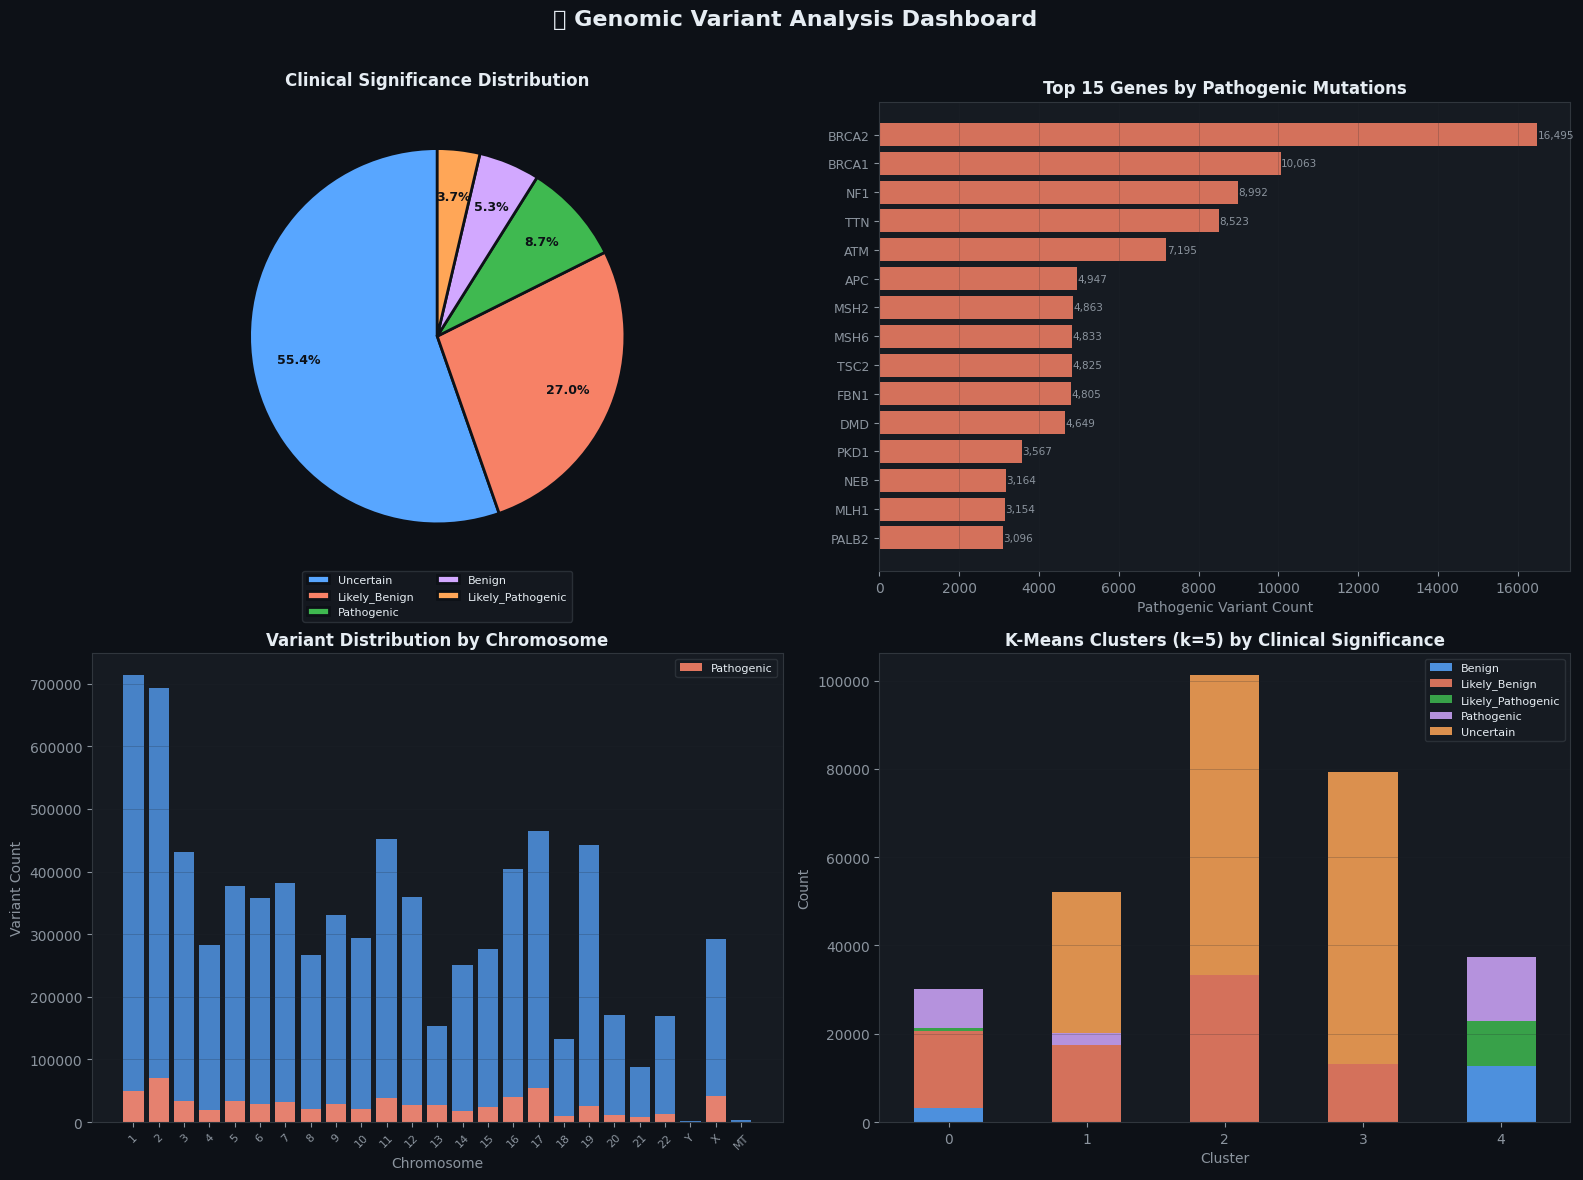

💾 Dashboard plot saved


In [34]:
# ── PLOT 1: Clinical Significance Distribution ────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🧬 Genomic Variant Analysis Dashboard', fontsize=16,
             color='#e6edf3', fontweight='bold', y=0.98)

# --- Subplot 1: ClinSig Pie Chart
ax1 = axes[0, 0]
clinsig_sorted = clinsig_pd.sort_values('count', ascending=False)
wedge_props = {'edgecolor': '#0d1117', 'linewidth': 2}
wedges, texts, autotexts = ax1.pie(
    clinsig_sorted['count'],
    labels=None,
    autopct='%1.1f%%',
    colors=ACCENT_COLORS[:len(clinsig_sorted)],
    wedgeprops=wedge_props,
    startangle=90,
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_color('#0d1117')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
ax1.legend(
    clinsig_sorted['ClinSig_Clean'],
    loc='lower center', fontsize=8,
    facecolor='#161b22', edgecolor='#30363d',
    labelcolor='#e6edf3', ncol=2,
    bbox_to_anchor=(0.5, -0.12)
)
ax1.set_title('Clinical Significance Distribution', color='#e6edf3', fontweight='bold', pad=12)

# --- Subplot 2: Top 15 Pathogenic Genes
ax2 = axes[0, 1]
top_genes = gene_agg_pd.nlargest(15, 'Pathogenic_Count')
bars = ax2.barh(
    top_genes['GeneSymbol'],
    top_genes['Pathogenic_Count'],
    color=ACCENT_COLORS[1],
    alpha=0.85,
    edgecolor='none'
)
ax2.set_xlabel('Pathogenic Variant Count', color='#8b949e')
ax2.set_title('Top 15 Genes by Pathogenic Mutations', color='#e6edf3', fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='y', labelsize=9)

# Add value labels
for bar, val in zip(bars, top_genes['Pathogenic_Count']):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', va='center', color='#8b949e', fontsize=7.5)

# --- Subplot 3: Chromosome Variant Count
ax3 = axes[1, 0]
chrom_sorted = chrom_agg_pd.copy()
# Sort chromosomes numerically
def chrom_sort_key(c):
    try: return int(c)
    except: return 100 if c == 'MT' else 99
chrom_sorted['sort_key'] = chrom_sorted['Chromosome'].apply(chrom_sort_key)
chrom_sorted = chrom_sorted.sort_values('sort_key')

bar_colors = [ACCENT_COLORS[0] if c in ['X', 'Y', 'MT'] else '#58a6ff'
              for c in chrom_sorted['Chromosome']]
ax3.bar(
    chrom_sorted['Chromosome'],
    chrom_sorted['Total_Variants'],
    color=ACCENT_COLORS[0], alpha=0.75, edgecolor='none'
)
ax3.bar(
    chrom_sorted['Chromosome'],
    chrom_sorted['Pathogenic_Variants'],
    color=ACCENT_COLORS[1], alpha=0.9, edgecolor='none',
    label='Pathogenic'
)
ax3.set_xlabel('Chromosome', color='#8b949e')
ax3.set_ylabel('Variant Count', color='#8b949e')
ax3.set_title('Variant Distribution by Chromosome', color='#e6edf3', fontweight='bold')
ax3.tick_params(axis='x', rotation=45, labelsize=8)
ax3.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# --- Subplot 4: Cluster Distribution Stacked Bar
ax4 = axes[1, 1]
cluster_pivot = cluster_pd.pivot(index='Cluster', columns='ClinSig_Clean', values='count').fillna(0)
cluster_pivot.plot(
    kind='bar', ax=ax4, stacked=True,
    color=ACCENT_COLORS[:len(cluster_pivot.columns)],
    alpha=0.85, edgecolor='none'
)
ax4.set_xlabel('Cluster', color='#8b949e')
ax4.set_ylabel('Count', color='#8b949e')
ax4.set_title(f'K-Means Clusters (k={OPTIMAL_K}) by Clinical Significance',
              color='#e6edf3', fontweight='bold')
ax4.tick_params(axis='x', rotation=0)
ax4.legend(title='', facecolor='#161b22', edgecolor='#30363d',
           labelcolor='#e6edf3', fontsize=8, loc='upper right')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{OUTPUTS_DIR}/dashboard_plot.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('💾 Dashboard plot saved')

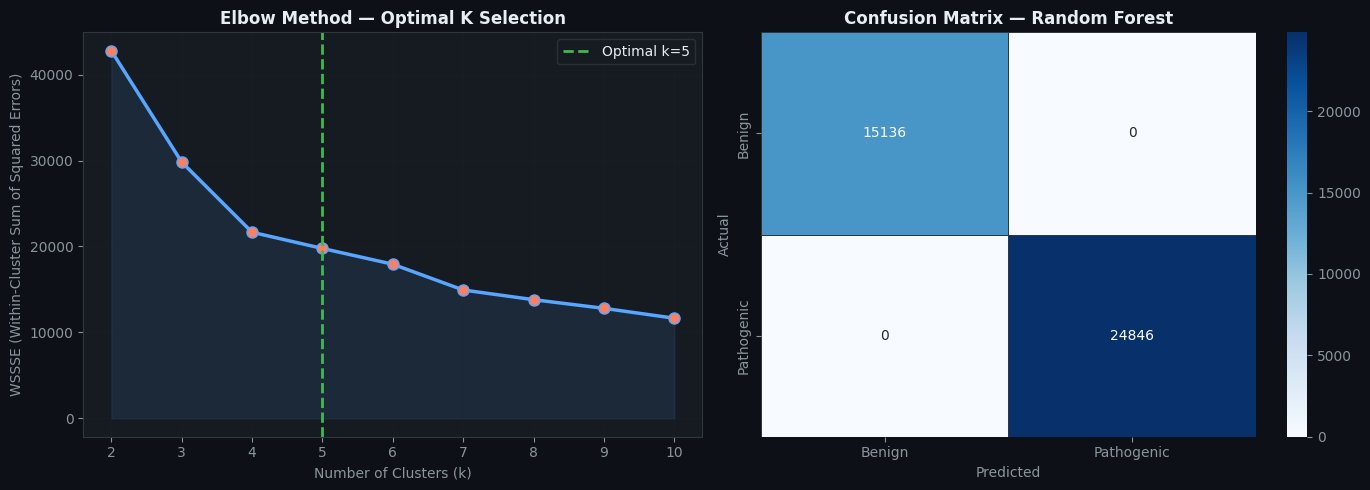

💾 Elbow + Confusion matrix plot saved


In [35]:
# ── PLOT 2: Elbow Curve ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Elbow curve
ax = axes[0]
ax.plot(K_RANGE, WSSSE_LIST, 'o-', color=ACCENT_COLORS[0],
        linewidth=2.5, markersize=8, markerfacecolor=ACCENT_COLORS[1])
ax.axvline(x=OPTIMAL_K, color=ACCENT_COLORS[2], linestyle='--',
           linewidth=2, label=f'Optimal k={OPTIMAL_K}')
ax.fill_between(K_RANGE, WSSSE_LIST, alpha=0.1, color=ACCENT_COLORS[0])
ax.set_xlabel('Number of Clusters (k)', color='#8b949e')
ax.set_ylabel('WSSSE (Within-Cluster Sum of Squared Errors)', color='#8b949e')
ax.set_title('Elbow Method — Optimal K Selection', color='#e6edf3', fontweight='bold')
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax.grid(alpha=0.3)
ax.set_xticks(K_RANGE)

# Confusion Matrix
ax2 = axes[1]
sns.heatmap(
    cm, annot=True, fmt='d', ax=ax2,
    cmap='Blues',
    xticklabels=['Benign', 'Pathogenic'],
    yticklabels=['Benign', 'Pathogenic'],
    linewidths=0.5, linecolor='#30363d'
)
ax2.set_title('Confusion Matrix — Random Forest', color='#e6edf3', fontweight='bold')
ax2.set_xlabel('Predicted', color='#8b949e')
ax2.set_ylabel('Actual', color='#8b949e')
ax2.tick_params(colors='#8b949e')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/elbow_and_confusion.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('💾 Elbow + Confusion matrix plot saved')

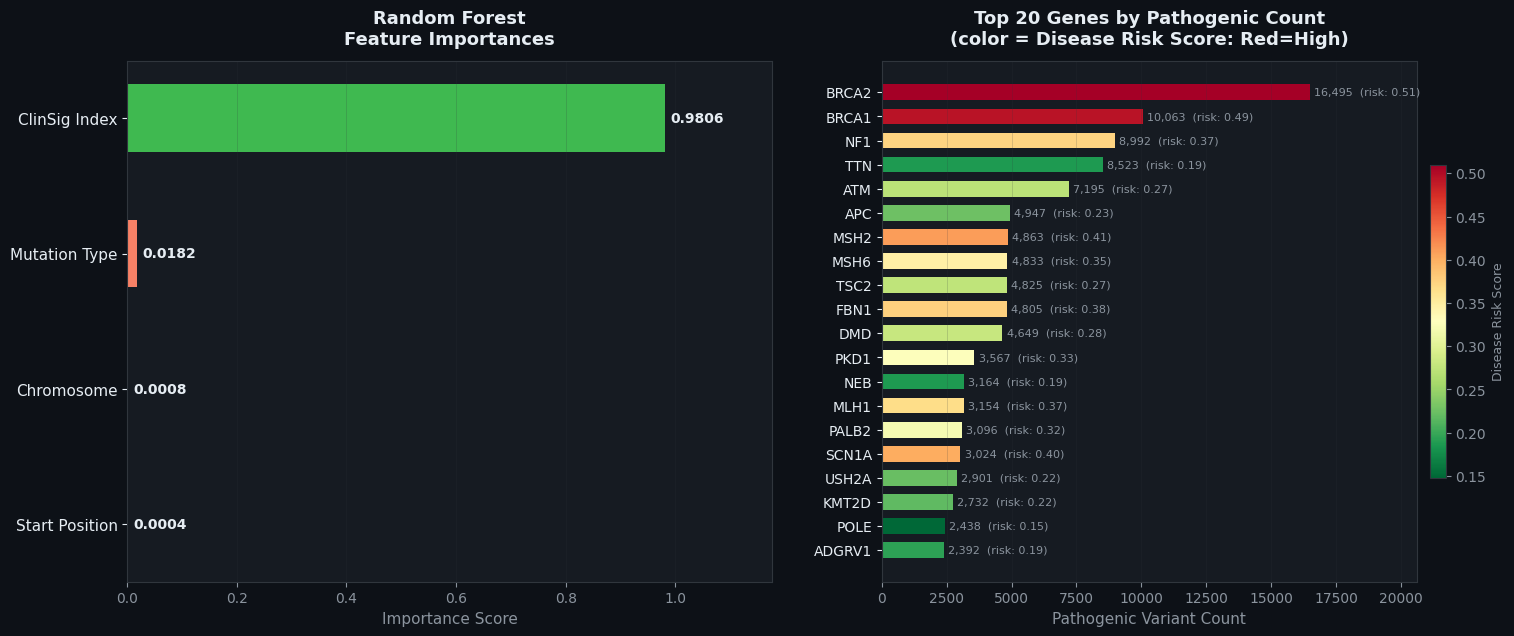

💾 Feature importance + gene risk plot saved (risk colors normalized to data range)


In [41]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Ensure OUTPUTS_DIR is defined (adjust path if needed)
# OUTPUTS_DIR = './outputs'   # uncomment if not already defined

# ── PLOT 3 (FINAL): Feature Importance + Top Genes Risk Score ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

# ─────────────────────────────────────────────
# LEFT: Feature Importances (distinct colors, labels)
# ─────────────────────────────────────────────
ax = axes[0]

feat_names = ['Start Position', 'ClinSig Index', 'Chromosome', 'Mutation Type']
feat_imp   = importances                         # must be defined
sorted_idx = np.argsort(feat_imp)                # ascending for horizontal bar

sorted_names  = [feat_names[i] for i in sorted_idx]
sorted_values = feat_imp[sorted_idx]

# Assign a distinct color per bar
bar_colors = ['#58a6ff', '#3fb950', '#ffa657', '#f78166']
bars = ax.barh(sorted_names, sorted_values,
               color=[bar_colors[i] for i in sorted_idx],
               height=0.5, edgecolor='none')

# Add value labels at end of each bar
for bar, val in zip(bars, sorted_values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', color='#e6edf3', fontsize=10, fontweight='bold')

ax.set_xlim(0, max(sorted_values) * 1.2)
ax.set_xlabel('Importance Score', color='#8b949e', fontsize=11)
ax.set_title('Random Forest\nFeature Importances', color='#e6edf3',
             fontweight='bold', fontsize=13, pad=12)
ax.tick_params(axis='y', labelsize=11, colors='#e6edf3')
ax.tick_params(axis='x', colors='#8b949e')
ax.grid(axis='x', alpha=0.25, color='#30363d')
ax.set_facecolor('#161b22')

# ─────────────────────────────────────────────
# RIGHT: Top 20 Single Genes by Pathogenic Count
# (Filter out multi-gene / subset entries)
# ─────────────────────────────────────────────
ax2 = axes[1]

# Filter: keep only true single gene symbols with at least 10 mutations
single_gene_df = gene_agg_pd[                       # must be defined
    (~gene_agg_pd['GeneSymbol'].str.contains(':', na=False)) &
    (~gene_agg_pd['GeneSymbol'].str.lower().str.contains('subset', na=False)) &
    (~gene_agg_pd['GeneSymbol'].str.lower().str.contains('intergenic', na=False)) &
    (gene_agg_pd['Total_Mutations'] >= 10)
].copy()

# Sort by Pathogenic Count (not ratio) for top genes
top_genes_fixed = single_gene_df.nlargest(20, 'Pathogenic_Count')

# --- Color bars by Disease Risk Score, but NORMALIZE to data range ---
risk_scores = top_genes_fixed['Disease_Risk_Score'].values
norm = mcolors.Normalize(vmin=risk_scores.min(), vmax=risk_scores.max())
colors_grad = plt.cm.RdYlGn_r(norm(risk_scores))   # Red=high, Green=low

bars2 = ax2.barh(
    top_genes_fixed['GeneSymbol'],
    top_genes_fixed['Pathogenic_Count'],
    color=colors_grad,
    height=0.65,
    edgecolor='none'
)

# Add count labels with risk score
for bar, val, risk in zip(bars2, top_genes_fixed['Pathogenic_Count'],
                          top_genes_fixed['Disease_Risk_Score']):
    ax2.text(bar.get_width() + top_genes_fixed['Pathogenic_Count'].max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{int(val):,}  (risk: {risk:.2f})',
             va='center', color='#8b949e', fontsize=8)

ax2.set_xlabel('Pathogenic Variant Count', color='#8b949e', fontsize=11)
ax2.set_title('Top 20 Genes by Pathogenic Count\n(color = Disease Risk Score: Red=High)',
              color='#e6edf3', fontweight='bold', fontsize=13, pad=12)
ax2.invert_yaxis()
ax2.tick_params(axis='y', labelsize=10, colors='#e6edf3')
ax2.tick_params(axis='x', colors='#8b949e')
ax2.grid(axis='x', alpha=0.25, color='#30363d')
ax2.set_facecolor('#161b22')
ax2.set_xlim(0, top_genes_fixed['Pathogenic_Count'].max() * 1.25)

# Colorbar legend (using the same normalized colormap)
sm = cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, shrink=0.6, pad=0.02)
cbar.set_label('Disease Risk Score', color='#8b949e', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#8b949e')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8b949e')

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUTPUTS_DIR}/feature_importance_risk.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('💾 Feature importance + gene risk plot saved (risk colors normalized to data range)')

---
## 💾 MODULE 8: FINAL OUTPUT & PERSISTENCE
### What happens here:
- Save final processed dataset (Parquet + CSV)
- Verify all model files exist in Drive
- Print complete directory listing
- Print persistence status table

**Expected Output:** All files saved, full directory listing printed

In [40]:
# ============================================================
# MODULE 8: FINAL OUTPUT DATASET
# ============================================================

FINAL_PARQUET = f'{OUTPUTS_DIR}/final_genomic_dataset'
FINAL_CSV     = f'{OUTPUTS_DIR}/final_genomic_dataset.csv'

print('⚙️  Preparing final output dataset...')

# ── Join features with cluster assignments ────────────────────
final_df = (
    features_df
    .join(
        clustered_df.select(
            'GeneSymbol', 'ClinSig_Clean',
            F.col('Chromosome').alias('Chr_cluster'),
            'Cluster'
        ),
        on=['GeneSymbol', 'ClinSig_Clean'],
        how='left'
    )
    .select(
        'GeneSymbol', 'ClinSig_Clean', 'Chromosome', 'Start',
        'Type', 'ClinSig_Index', 'Chrom_Index', 'Type_Index', 'Cluster'
    )
)

# ── Save as Parquet (optimal for Big Data pipelines) ─────────
if not checkpoint_exists(FINAL_PARQUET):
    save_parquet(final_df, FINAL_PARQUET, 'FINAL_PARQUET')
else:
    print(f'  ✅ [FINAL_PARQUET] Already exists → {FINAL_PARQUET}')

# ── Save as CSV (for dashboards, Excel, sharing) ─────────────
if not checkpoint_exists(FINAL_CSV):
    (
        final_df
        .coalesce(1)  # Merge into single CSV file
        .write.mode('overwrite')
        .option('header', 'true')
        .csv(FINAL_CSV)
    )
    print(f'  💾 [FINAL_CSV] Saved → {FINAL_CSV}')
else:
    print(f'  ✅ [FINAL_CSV] Already exists → {FINAL_CSV}')

print(f'\n📊 Final Dataset Stats:')
print(f'   Total Records  : {final_df.count():,}')
print(f'   Columns        : {len(final_df.columns)}')
print(f'   Columns        : {final_df.columns}')
print('\n📊 Final Dataset Sample:')
final_df.show(10, truncate=30)

⚙️  Preparing final output dataset...
   ⏳ Saving FINAL_PARQUET to Parquet: /content/drive/MyDrive/genomic_project/outputs/final_genomic_dataset
   ✅ FINAL_PARQUET saved in 716.3 seconds
  💾 [FINAL_CSV] Saved → /content/drive/MyDrive/genomic_project/outputs/final_genomic_dataset.csv

📊 Final Dataset Stats:
   Total Records  : 399,917,301
   Columns        : 9
   Columns        : ['GeneSymbol', 'ClinSig_Clean', 'Chromosome', 'Start', 'Type', 'ClinSig_Index', 'Chrom_Index', 'Type_Index', 'Cluster']

📊 Final Dataset Sample:
+----------+-------------+----------+--------+-------------------------+-------------+-----------+----------+-------+
|GeneSymbol|ClinSig_Clean|Chromosome|   Start|                     Type|ClinSig_Index|Chrom_Index|Type_Index|Cluster|
+----------+-------------+----------+--------+-------------------------+-------------+-----------+----------+-------+
|      A1CF|    Uncertain|        10|50828188|single nucleotide variant|          0.0|       12.0|       0.0|      3|
|

In [42]:
# ============================================================
# PERSISTENCE STATUS REPORT
# ============================================================

print('='*65)
print('  📁 GOOGLE DRIVE PERSISTENCE STATUS REPORT')
print('='*65)

checkpoints = [
    ('Dataset (.gz)',           DATASET_PATH),
    ('Raw Parquet Checkpoint',  RAW_PARQUET),
    ('Preprocessed Data',       PREPROCESSED_PARQUET),
    ('Feature Engineered Data', FEATURES_PARQUET),
    ('Clustered Data',          CLUSTERED_PARQUET),
    ('RF Predictions',          PREDICTIONS_PARQUET),
    ('K-Means Model',           KMEANS_MODEL_PATH),
    ('Random Forest Model',     RF_MODEL_PATH),
    ('Elbow Data',              ELBOW_DATA_PATH),
    ('Evaluation Results',      EVAL_RESULTS_PATH),
    ('Dashboard Plot',          f'{OUTPUTS_DIR}/dashboard_plot.png'),
    ('Elbow+Confusion Plot',    f'{OUTPUTS_DIR}/elbow_and_confusion.png'),
    ('Feature Importance Plot', f'{OUTPUTS_DIR}/feature_importance_risk.png'),
    ('Final Parquet Output',    FINAL_PARQUET),
    ('Final CSV Output',        FINAL_CSV),
]

print(f'  {"Name":<30} {"Status":<12} {"Path"}')
print(f'  {"-"*28} {"-"*10} {"-"*30}')
all_saved = True
for name, path in checkpoints:
    exists = checkpoint_exists(path)
    status = '✅ EXISTS' if exists else '❌ MISSING'
    if not exists:
        all_saved = False
    short_path = path.replace('/content/drive/MyDrive/genomic_project/', '…/')
    print(f'  {name:<30} {status:<12} {short_path}')

print('='*65)
if all_saved:
    print('  🎉 ALL CHECKPOINTS SAVED — Next run will skip all recomputation!')
else:
    print('  ⚠️  Some checkpoints missing — re-run above cells to generate them.')
print('='*65)

  📁 GOOGLE DRIVE PERSISTENCE STATUS REPORT
  Name                           Status       Path
  ---------------------------- ---------- ------------------------------
   ✅ Checkpoint exists: /content/drive/MyDrive/genomic_project/data/variant_summary.txt.gz
  Dataset (.gz)                  ✅ EXISTS     …/data/variant_summary.txt.gz
   ✅ Checkpoint exists: /content/drive/MyDrive/genomic_project/processed/raw_spark_df
  Raw Parquet Checkpoint         ✅ EXISTS     …/processed/raw_spark_df
   ✅ Checkpoint exists: /content/drive/MyDrive/genomic_project/processed/preprocessed_df
  Preprocessed Data              ✅ EXISTS     …/processed/preprocessed_df
   ✅ Checkpoint exists: /content/drive/MyDrive/genomic_project/processed/features_df
  Feature Engineered Data        ✅ EXISTS     …/processed/features_df
   ✅ Checkpoint exists: /content/drive/MyDrive/genomic_project/processed/clustered_df
  Clustered Data                 ✅ EXISTS     …/processed/clustered_df
   ✅ Checkpoint exists: /content/d

In [43]:
# ============================================================
# FINAL SUMMARY — PROJECT COMPLETE
# ============================================================

print()
print('╔══════════════════════════════════════════════════════════════╗')
print('║   🧬 GENOMIC RARE DISEASE PIPELINE — EXECUTION COMPLETE      ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║                                                              ║')
print('║  MODULE 1  ✅  Data Ingestion (ClinVar 2M+ records)          ║')
print('║  MODULE 2  ✅  Preprocessing (cleaning, dedup, filtering)    ║')
print('║  MODULE 3  ✅  Feature Engineering (encoding, normalization) ║')
print('║  MODULE 4  ✅  Distributed Processing (Spark aggregations)   ║')
print('║  MODULE 5  ✅  ML Modeling (K-Means + Random Forest)         ║')
print('║  MODULE 6  ✅  Evaluation (Silhouette, Accuracy, F1, etc.)   ║')
print('║  MODULE 7  ✅  Visualization (3 dashboard plots)             ║')
print('║  MODULE 8  ✅  Final Output (Parquet + CSV saved to Drive)   ║')
print('║                                                              ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  All outputs saved to:                                       ║')
print('║  /content/drive/MyDrive/genomic_project/                     ║')
print('║                                                              ║')
print('║  Run 2+ will load all checkpoints — ZERO recomputation.      ║')
print('╚══════════════════════════════════════════════════════════════╝')
print()

spark.stop()
print('✅ Spark session stopped cleanly.')


╔══════════════════════════════════════════════════════════════╗
║   🧬 GENOMIC RARE DISEASE PIPELINE — EXECUTION COMPLETE      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  MODULE 1  ✅  Data Ingestion (ClinVar 2M+ records)          ║
║  MODULE 2  ✅  Preprocessing (cleaning, dedup, filtering)    ║
║  MODULE 3  ✅  Feature Engineering (encoding, normalization) ║
║  MODULE 4  ✅  Distributed Processing (Spark aggregations)   ║
║  MODULE 5  ✅  ML Modeling (K-Means + Random Forest)         ║
║  MODULE 6  ✅  Evaluation (Silhouette, Accuracy, F1, etc.)   ║
║  MODULE 7  ✅  Visualization (3 dashboard plots)             ║
║  MODULE 8  ✅  Final Output (Parquet + CSV saved to Drive)   ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  All outputs saved to:                                       ║
║  /content/drive/MyDrive/genomic

In [49]:
from google.colab import drive
import os

# Use a different mountpoint to avoid the "non-empty" error
MOUNT_POINT = '/content/drive2'
drive.mount(MOUNT_POINT)

# Path to your project folder inside Google Drive
PROJECT_PATH = os.path.join(MOUNT_POINT, 'MyDrive', 'genomic_project')

# Check if the project folder exists
if not os.path.exists(PROJECT_PATH):
    print(f'❌ Folder not found: {PROJECT_PATH}')
    print('   Please verify the path and try again.')
else:
    # Zip the folder (use -r for recursive, -q for quiet to reduce output)
    !zip -r project.zip "$PROJECT_PATH"

    # Download the zip file
    from google.colab import files
    files.download('project.zip')
    print('✅ Download initiated.')

ValueError: mount failed